<a href="https://colab.research.google.com/github/InnovativeCoder/MiniGpt-20m-jax/blob/main/MiniGPT_20m_jax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!nvidia-smi

Tue Mar 17 14:48:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
import jax
import jax.numpy as jnp
import grain.python as grain
from pathlib import Path
# Removed failing helper import

print("Available JAX devices:")
for i, device in enumerate(jax.devices()):
    print(f"Device {i}: {device.device_kind}, Backend: {device.platform}, ID: {device.id}")

if 'gpu' in [device.platform for device in jax.devices()]:
    print("\nJAX has detected a GPU backend.")
else:
    print("\nJAX has not detected a GPU backend. It is likely running on CPU.")

Available JAX devices:
Device 0: Tesla T4, Backend: gpu, ID: 0

JAX has detected a GPU backend.


In [10]:
!pip install tiktoken
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
tokenizer.n_vocab

50257

In [11]:
print(tokenizer.encode("hello world"))
tokenizer.decode([31373, 995])

[31373, 995]


'hello world'

In [12]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx

import matplotlib.pyplot as plt

In [13]:
class TokenAndPositionEmbedding(nnx.Module):
    def __init__(self, maxlen, vocab_size, embed_dim, *, rngs):
        self.token_emb = nnx.Embed(vocab_size, embed_dim, rngs=rngs)
        self.pos_emb = nnx.Embed(maxlen, embed_dim, rngs=rngs)

    def __call__(self, x):
        seq_len = x.shape[1]
        positions = jnp.arange(seq_len)[None, :]
        return self.token_emb(x) + self.pos_emb(positions)

In [14]:
# Let's look at the actual 'Embedding Table' inside the layer
# This is a matrix where each row represents one token in the vocabulary.

# Initialize the layer with small dimensions for clarity
vocab_size = 50257
embed_dim = 4
rngs = nnx.Rngs(0)
model = TokenAndPositionEmbedding(10, vocab_size, embed_dim, rngs=rngs)

# Access the raw weight matrix (the Table)
# Note: in nnx.Embed, the attribute is .embedding (singular)
token_embedding_table = model.token_emb.embedding.value

print(f"The Embedding Table shape is: {token_embedding_table.shape}")
print(f"(Total Tokens: {vocab_size}, Numbers per Token: {embed_dim})")

# Let's look at a specific word: 'hello' -> ID 31373
token_id = 31373
print(f"\nThe vector for token ID {token_id} is:")
print(token_embedding_table[token_id])

print("\nThis vector is what the transformer actually 'sees' instead of the word 'hello'.")

The Embedding Table shape is: (50257, 4)
(Total Tokens: 50257, Numbers per Token: 4)

The vector for token ID 31373 is:
[ 0.20275228 -0.61367816 -0.69134337 -0.47267267]

This vector is what the transformer actually 'sees' instead of the word 'hello'.


In [15]:
# Let's look at the 'Position Table' inside the same model
pos_embedding_table = model.pos_emb.embedding.value

print(f"Position Table Shape: {pos_embedding_table.shape}")
print(f"(Max Sentence Length: 10, Numbers per Position: 4)")

# Let's see the vector for 'Position 0' (where 'hello' is)
print(f"\nVector for Position 0:")
print(pos_embedding_table[0])

# Now, let's see what the Transformer actually gets for 'hello' at the start of a sentence:
# Combined = Token Vector + Position Vector
combined = token_embedding_table[31373] + pos_embedding_table[0]

print("\n--- The Final Math ---")
print(f"Token Vector (hello):    {token_embedding_table[31373]}")
print(f"+ Position Vector (pos0): {pos_embedding_table[0]}")
print(f"= Final Input to Block:  {combined}")

Position Table Shape: (10, 4)
(Max Sentence Length: 10, Numbers per Position: 4)

Vector for Position 0:
[-1.2212279  -1.0178403   0.10277212 -0.1767751 ]

--- The Final Math ---
Token Vector (hello):    [ 0.20275228 -0.61367816 -0.69134337 -0.47267267]
+ Position Vector (pos0): [-1.2212279  -1.0178403   0.10277212 -0.1767751 ]
= Final Input to Block:  [-1.0184757  -1.6315184  -0.58857125 -0.6494478 ]


In [16]:
def causal_attention_mask(seq_len):
    return jnp.tril(jnp.ones((seq_len, seq_len)))

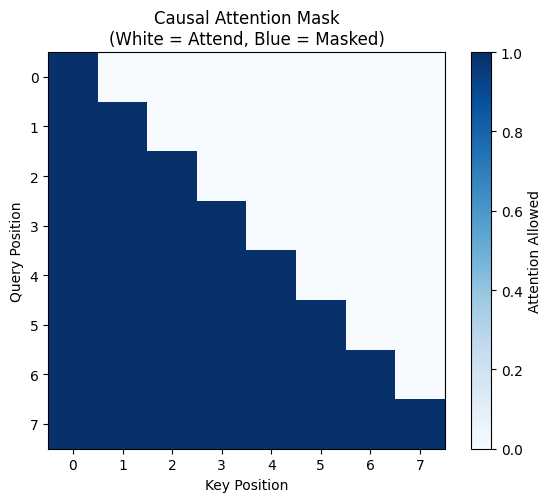

In [17]:
mask = causal_attention_mask(8)
plt.figure(figsize=(6, 5))
plt.imshow(mask, cmap='Blues', interpolation='nearest')
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.title('Causal Attention Mask\n(White = Attend, Blue = Masked)')
plt.colorbar(label='Attention Allowed')
plt.tight_layout()
plt.show()

In [18]:
class TransformerBlock(nnx.Module):

    def __init__(self, embed_dim, num_heads, ff_dim, *, rngs):
        self.attention = nnx.MultiHeadAttention(
            num_heads=num_heads,
            in_features=embed_dim,
            qkv_features=embed_dim,
            out_features=embed_dim,
            decode=False,
            rngs=rngs
        )

    def __call__(self, x, mask=None):
        attn_out = self.attention(x, mask=mask)
        x = x + attn_out
        return x

In [19]:
class MiniGPT(nnx.Module):

    def __init__(self, maxlen, vocab_size, embed_dim, num_heads,
                 feed_forward_dim, num_transformer_blocks, *, rngs):
        self.maxlen = maxlen
        self.embedding = TokenAndPositionEmbedding(maxlen, vocab_size,
                                                   embed_dim, rngs=rngs)
        self.transformer_blocks = [
            TransformerBlock(embed_dim, num_heads, feed_forward_dim,
                             rngs=rngs)
            for _ in range(num_transformer_blocks)
        ]
        self.output_layer = nnx.Linear(embed_dim, vocab_size,
                                       use_bias=False, rngs=rngs)

    def causal_attention_mask(self, seq_len):
        return jnp.tril(jnp.ones((seq_len, seq_len)))

    def __call__(self, token_ids):
        seq_len = token_ids.shape[1]
        mask = self.causal_attention_mask(seq_len)
        x = self.embedding(token_ids)
        for block in self.transformer_blocks:
            x = block(x, mask=mask)

        logits = self.output_layer(x)
        return logits

In [20]:
model = MiniGPT(
    maxlen=128,
    vocab_size=tokenizer.n_vocab,
    embed_dim=192,
    num_heads=6,
    feed_forward_dim = 512,
    num_transformer_blocks=6,
    rngs=nnx.Rngs(0)
)

In [21]:
model

MiniGPT( # Param: 20,212,608 (80.9 MB)
  maxlen=128,
  embedding=TokenAndPositionEmbedding( # Param: 9,673,920 (38.7 MB)
    token_emb=Embed( # Param: 9,649,344 (38.6 MB)
      embedding=Param( # 9,649,344 (38.6 MB)
        value=Array(shape=(50257, 192), dtype=dtype('float32'))
      ),
      num_embeddings=50257,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      embedding_init=<function variance_scaling.<locals>.init at 0x791cbf5a45e0>,
      promote_dtype=<function promote_dtype at 0x791ca01776a0>
    ),
    pos_emb=Embed( # Param: 24,576 (98.3 KB)
      embedding=Param( # 24,576 (98.3 KB)
        value=Array(shape=(128, 192), dtype=dtype('float32'))
      ),
      num_embeddings=128,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      embedding_init=<function variance_scaling.<locals>.init at 0x791cbf5a45e0>,
      promote_dtype=<function promote_dtype at 0x791ca01776a0>
    )
  ),
  transformer_blocks=[TransformerBloc

In [22]:
# Data Loading
!pip install -q datasets
from datasets import load_dataset

# Load the first 1000 stories for training
dataset = load_dataset("roneneldan/TinyStories", split="train[:1000]")

# Verify
print(f"Dataset loaded: {len(dataset)} examples.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Dataset loaded: 1000 examples.


In [23]:
import numpy as np

class StoryDataset:
    def __init__(self, stories, maxlen, tokenizer):
        self.stories = stories
        self.maxlen = maxlen
        self.tokenizer = tokenizer
        self.end_token = tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'})[0]

    def __len__(self):
        return len(self.stories)

    def __getitem__(self, idx):
        story = self.stories[idx]
        tokens = self.tokenizer.encode(story, allowed_special={'<|endoftext|>'})

        if len(tokens) > self.maxlen:
            tokens = tokens[:self.maxlen]
        else:
            tokens.extend([0] * (self.maxlen - len(tokens)))

        return np.array(tokens, dtype=np.int32)

In [24]:
# Data iterator
shuffled_sampler = grain.IndexSampler(
    num_records=10,
    shuffle=True,
    seed=42,
    shard_options=grain.NoSharding(),
    num_epochs=1
)

def print_sampler_example(sampler, name):
    print(f"\n{name}")
    for i, idx in enumerate(sampler):
        print(f"Record {i}: {idx}")

print_sampler_example(shuffled_sampler, "Shuffled sampler")



Shuffled sampler
Record 0: RecordMetadata(index=0, record_key=8, rng=Generator(Philox))
Record 1: RecordMetadata(index=1, record_key=6, rng=Generator(Philox))
Record 2: RecordMetadata(index=2, record_key=7, rng=Generator(Philox))
Record 3: RecordMetadata(index=3, record_key=9, rng=Generator(Philox))
Record 4: RecordMetadata(index=4, record_key=0, rng=Generator(Philox))
Record 5: RecordMetadata(index=5, record_key=5, rng=Generator(Philox))
Record 6: RecordMetadata(index=6, record_key=1, rng=Generator(Philox))
Record 7: RecordMetadata(index=7, record_key=2, rng=Generator(Philox))
Record 8: RecordMetadata(index=8, record_key=4, rng=Generator(Philox))
Record 9: RecordMetadata(index=9, record_key=3, rng=Generator(Philox))


In [25]:
#Batching
batch_op_keep = grain.Batch(
    batch_size=32,
    drop_remainder=False
)

In [26]:
def create_dataloader(
    stories,
    tokenizer,
    maxlen,
    batch_size,
    shuffle = False,
    num_epochs = 1,
    seed = 42,
    worker_count = 0
):
    dataset = StoryDataset(stories, maxlen, tokenizer)
    estimated_batches = len(dataset) // batch_size

    sampler = grain.IndexSampler(
        num_records=len(dataset), # 1,000 stories for this dataset
        shuffle=shuffle,
        seed=seed,
        shard_options=grain.NoSharding(),
        num_epochs=num_epochs
    )
    dataloader = grain.DataLoader(
        data_source=dataset,
        sampler=sampler,
        operations=[
            grain.Batch(batch_size=batch_size, drop_remainder=True)
        ],
        worker_count=worker_count
    )

    return dataloader, estimated_batches

In [27]:
# Use the 'text' column from the dataset we already loaded via Hugging Face
stories = dataset['text']
print(f"Successfully retrieved {len(stories)} stories from the Hugging Face dataset.")

Successfully retrieved 1000 stories from the Hugging Face dataset.


In [28]:
# Create the dataloader
batch_size = 32
maxlen = 128

train_loader, steps_per_epoch = create_dataloader(
    stories=stories,
    tokenizer=tokenizer,
    maxlen=maxlen,
    batch_size=batch_size,
    shuffle=True,
    num_epochs=1
)

print(f"we have steps per epoch {steps_per_epoch}")
# Inspect the first batch
first_batch = next(iter(train_loader))
# Convert to numpy array for inspection if it isn't already
first_batch_np = np.array(first_batch)

print(f"Batch shape: {first_batch_np.shape}")
print(f"First sequence of the batch (IDs):\n{first_batch_np[0][:20]}...")
print(f"\nDecoded start of first sequence:\n{tokenizer.decode(first_batch_np[0].tolist()[:50])}")

we have steps per epoch 31
Batch shape: (32, 128)
First sequence of the batch (IDs):
[ 7454   612   373   257  1310  2576  3706 47882   508  6151   284   711
  2354    13  1439   286   607  4004  1243   284]...

Decoded start of first sequence:
Once there was a little girl named Becky who loved to play outside. All of her favorite things to do were running, jumping and playing hide-and-seek.

One day, when Becky was playing outside, it started to get really cold


In [29]:
next(iter(train_loader))

array([[ 7454,   612,   373, ...,  3114,   588,   340],
       [ 7454,  2402,   257, ...,    13,   554,  2166],
       [ 7454,  2402,   257, ...,   257, 13373,   673],
       ...,
       [ 7454,  2402,   257, ...,   198,   198,   464],
       [ 7454,  2402,   257, ...,  1310,  2933,   550],
       [ 7454,  2402,   257, ...,   673,  1043,    13]], dtype=int32)

In [30]:
import optax

In [31]:
def loss_fn(model, batch):
    inputs, targets = batch
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits, targets
    ).mean()
    return loss, logits

In [32]:
num_epochs=3
total_steps = steps_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Total training steps: 93
Warmup steps: 9


In [33]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5
)

In [36]:
optimizer = nnx.ModelAndOptimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01)
)
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

In [37]:
@nnx.jit
def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1])
    optimizer.update(grads)

In [39]:
metrics_history = {'train_loss': []}

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

for epoch in range(num_epochs):
    step = 0
    for batch in train_loader:
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch(
            jnp.array(jnp.array(batch).T)).astype(jnp.int32)
        print(".", end="")
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 2 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value)
            metrics.reset()

            current_lr = lr_schedule(step)
            print(f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                  f"LR: {current_lr:.2e}")
        step += 1

..
Epoch: 1, Step 2, Loss: 10.8832, LR: 3.33e-05
..
Epoch: 1, Step 4, Loss: 10.8493, LR: 1.00e-04
..
Epoch: 1, Step 6, Loss: 10.7352, LR: 1.67e-04
..
Epoch: 1, Step 8, Loss: 10.5502, LR: 2.33e-04
..
Epoch: 1, Step 10, Loss: 10.2652, LR: 3.00e-04
..
Epoch: 1, Step 12, Loss: 9.9114, LR: 3.00e-04
..
Epoch: 1, Step 14, Loss: 9.6387, LR: 2.98e-04
..
Epoch: 1, Step 16, Loss: 9.2057, LR: 2.96e-04
..
Epoch: 1, Step 18, Loss: 8.9543, LR: 2.94e-04
..
Epoch: 1, Step 20, Loss: 8.6299, LR: 2.90e-04
..
Epoch: 1, Step 22, Loss: 8.4919, LR: 2.86e-04
..
Epoch: 1, Step 24, Loss: 8.1633, LR: 2.81e-04
..
Epoch: 1, Step 26, Loss: 7.9133, LR: 2.75e-04
..
Epoch: 1, Step 28, Loss: 7.7217, LR: 2.68e-04
..
Epoch: 1, Step 30, Loss: 7.4730, LR: 2.61e-04
...
Epoch: 2, Step 2, Loss: 7.2182, LR: 3.33e-05
..
Epoch: 2, Step 4, Loss: 6.9534, LR: 1.00e-04
..
Epoch: 2, Step 6, Loss: 6.7923, LR: 1.67e-04
..
Epoch: 2, Step 8, Loss: 6.6994, LR: 2.33e-04
..
Epoch: 2, Step 10, Loss: 6.6130, LR: 3.00e-04
..
Epoch: 2, Step 12, 

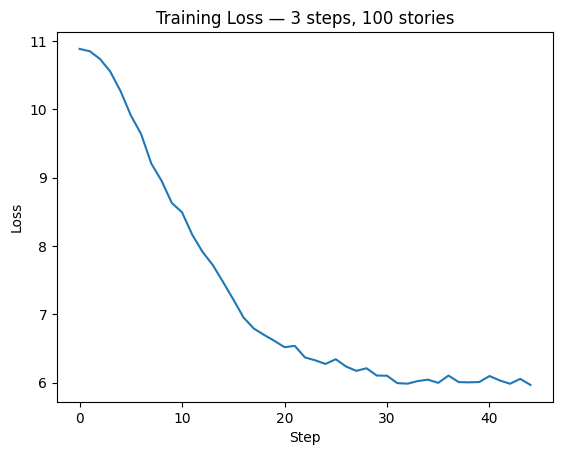

In [40]:
import matplotlib.pyplot as plt
plt.plot(metrics_history['train_loss'])
plt.title('Training Loss — 3 steps, 100 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [41]:
from pathlib import Path
import orbax

checkpoint_path = Path.cwd() / "small_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as /content/small_checkpoint.orbax
